
Limiting distribution pi:
   C: 0.1761
  C#: 0.0083
   D: 0.1209
  D#: 0.0057
   E: 0.1174
   F: 0.0780
  F#: 0.0153
   G: 0.1904
  G#: 0.0027
   A: 0.1645
  A#: 0.0128
   B: 0.1082

Total variation distance  ||P^n(i,.) - pi||_TV
start           n=2         n=4         n=8        n=10        n=12
    C     6.583e-02   8.215e-03   1.660e-04   2.370e-05   3.006e-06
   C#     1.381e-01   1.651e-02   2.765e-04   3.085e-05   3.166e-06
    D     1.094e-01   1.696e-02   3.356e-04   4.037e-05   4.443e-06
   D#     9.079e-02   8.121e-03   1.304e-04   1.698e-05   2.024e-06
    E     9.873e-02   1.325e-02   1.783e-04   1.827e-05   1.727e-06
    F     8.992e-02   8.034e-03   9.258e-05   1.360e-05   2.148e-06
   F#     8.884e-02   9.913e-03   2.186e-04   2.846e-05   3.362e-06
    G     5.724e-02   6.998e-03   1.580e-04   2.051e-05   2.415e-06
   G#     1.080e-01   7.748e-03   6.927e-05   6.236e-06   5.603e-07
    A     1.054e-01   1.631e-02   3.019e-04   3.554e-05   3.827e-06
   A#     6.802e-02  

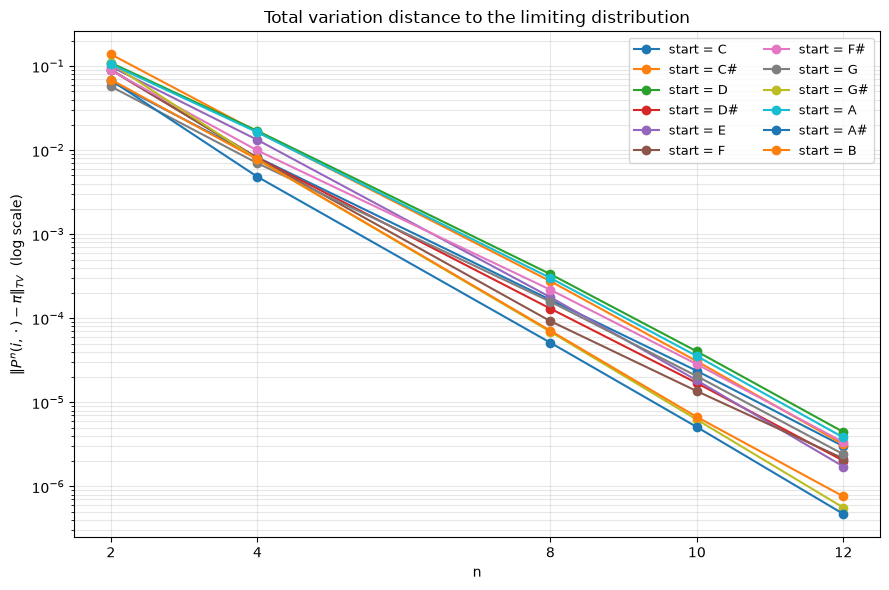

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

notes = ["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"]

P = np.array([
    [0.21, 0.00, 0.20, 0.01, 0.12, 0.05, 0.01, 0.10, 0.00, 0.09, 0.01, 0.20],
    [0.06, 0.06, 0.22, 0.06, 0.22, 0.06, 0.06, 0.06, 0.05, 0.05, 0.05, 0.05],
    [0.29, 0.01, 0.16, 0.00, 0.27, 0.10, 0.03, 0.08, 0.00, 0.03, 0.00, 0.03],
    [0.07, 0.07, 0.06, 0.06, 0.06, 0.06, 0.06, 0.06, 0.06, 0.25, 0.06, 0.13],
    [0.07, 0.01, 0.28, 0.00, 0.14, 0.16, 0.03, 0.19, 0.00, 0.10, 0.02, 0.00],
    [0.02, 0.01, 0.04, 0.01, 0.29, 0.05, 0.01, 0.43, 0.01, 0.09, 0.01, 0.03],
    [0.15, 0.03, 0.03, 0.03, 0.06, 0.03, 0.03, 0.29, 0.03, 0.26, 0.03, 0.03],
    [0.17, 0.01, 0.05, 0.00, 0.07, 0.11, 0.01, 0.25, 0.00, 0.22, 0.02, 0.09],
    [0.09, 0.09, 0.09, 0.09, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08],
    [0.09, 0.00, 0.06, 0.00, 0.02, 0.03, 0.01, 0.30, 0.00, 0.27, 0.01, 0.21],
    [0.20, 0.04, 0.04, 0.04, 0.20, 0.04, 0.04, 0.04, 0.04, 0.20, 0.08, 0.04],
    [0.38, 0.01, 0.07, 0.01, 0.02, 0.06, 0.00, 0.04, 0.00, 0.29, 0.00, 0.12],
])



eigvals, eigvecs = np.linalg.eig(P.T)
k = np.argmin(np.abs(eigvals - 1))
pi = np.real(eigvecs[:, k])
pi = pi / pi.sum()

print("\nLimiting distribution pi:")
for note, p in zip(notes, pi):
    print(f"  {note:>2}: {p:.4f}")

ns = [2, 4, 8, 10, 12]
tv = np.zeros((len(notes), len(ns)))  

for k, n in enumerate(ns):
    Pn = np.linalg.matrix_power(P, n)
    tv[:, k] = 0.5 * np.abs(Pn - pi).sum(axis=1)

print("\nTotal variation distance  ||P^n(i,.) - pi||_TV")
print("start  " + "".join(f"{'n='+str(n):>12}" for n in ns))
for i, note in enumerate(notes):
    print(f"{note:>5}  " + "".join(f"{tv[i, k]:>12.3e}" for k in range(len(ns))))

plt.figure(figsize=(9, 6))
for i, note in enumerate(notes):
    plt.plot(ns, tv[i], marker="o", label=f"start = {note}")
plt.yscale("log")
plt.xticks(ns)
plt.xlabel("n")
plt.ylabel(r"$\|P^n(i,\cdot) - \pi\|_{TV}$  (log scale)")
plt.title("Total variation distance to the limiting distribution")
plt.legend(ncol=2, fontsize=9)
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.savefig("tv_distance.png", dpi=150)
plt.show()